# Genetic Algorithm for Fashion Outfit Recommendation

This notebook walks through **every stage** of our GA pipeline, from candidate retrieval to final outfit selection.

Each section corresponds to a core GA component:
1. **Candidate Retrieval** from Knowledge Graph
2. **Population Initialisation**
3. **Fitness Function**
4. **Selection** (Tournament)
5. **Crossover** (Swap Top/Bottom)
6. **Mutation** (Replace from Pool)
7. **Elitism** (Preserve Best)
8. **Termination** & Evolution Loop
9. **Diverse Post-Selection** (Softmax Sampling)

---
## 0. Setup & Imports

In [1]:
import random
import pandas as pd
import numpy as np
import joblib
from neo4j import GraphDatabase
import warnings
warnings.filterwarnings('ignore')

# --- Paths ---
DATA_DIR = "../data/processed"
ARTICLES_PATH = "../services/recommender-service/kg/clean_articles_df.joblib"

# --- Neo4j connection (KG is running in Docker) ---
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "password123"
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

# Quick test
with driver.session() as session:
    result = session.run("MATCH (n) RETURN count(n) AS total")
    print(f"Neo4j connected. Total nodes: {result.single()['total']}")

print("Setup complete.")

Neo4j connected. Total nodes: 116538
Setup complete.


---
## 1. Candidate Retrieval from Knowledge Graph

Before the GA can run, we need a **candidate pool** of possible outfit pairs (top + bottom).

We query our Neo4j Knowledge Graph with user preferences:
- **Category** (e.g., Ladieswear, Menswear)
- **Max price** per item
- **Preferred colours**
- **Occasion** (e.g., Casual, Party)

The KG contains pre-computed `best_matches_with` edges between compatible tops and bottoms (based on lift analysis from purchase data).

In [2]:
# --- User Preferences (Simulate a request) ---
CATEGORY = "Ladieswear"
PREFERRED_COLORS = []          # empty = no colour preference
AVOID_COLORS = []
MAX_PRICE = 100.0              # max price per item
OCCASION = "Casual"   
NUM_OUTFITS = 3

print(f"User Request:")
print(f"  Category:         {CATEGORY}")
print(f"  Max Price:        ${MAX_PRICE}")
print(f"  Occasion:         {OCCASION}")
print(f"  Preferred Colors: {PREFERRED_COLORS or 'Any'}")
print(f"  Avoid Colors:     {AVOID_COLORS or 'None'}")
print(f"  Num Outfits:      {NUM_OUTFITS}")

User Request:
  Category:         Ladieswear
  Max Price:        $100.0
  Occasion:         Casual
  Preferred Colors: Any
  Avoid Colors:     None
  Num Outfits:      3


In [3]:
import os

def query_neo4j(category, preferred_colors, max_price, occasion=None, season=None, top_limit=100):
    """Query Neo4j KG for candidate top-bottom pairs."""
    query_parts = [
        "MATCH (top:Item)-[:in_category]->(cat:Attribute) WHERE cat.id = ($category + ' Top')",
        "MATCH (top)-[:has_price]->(price:Attribute) WHERE toFloat(price.id) <= $max_price"
    ]

    if preferred_colors:
        query_parts.append("MATCH (top)-[:has_color]->(col:Attribute) WHERE col.id IN $preferred_colors")
    if occasion:
        query_parts.append("MATCH (top)-[:has_occasion]->(occ:Attribute) WHERE toLower(occ.id) = toLower($occasion)")
    if season:
        query_parts.append("MATCH (top)-[:has_season]->(sea:Attribute) WHERE toLower(sea.id) = toLower($season)")

    final_query = "\n".join(query_parts) + """
    WITH DISTINCT top
    WITH top, rand() AS r
    ORDER BY r
    LIMIT $top_limit

    MATCH (top)-[match:best_matches_with]->(bottom:Item)

    OPTIONAL MATCH (top)-[:has_price]->(top_price)
    OPTIONAL MATCH (top)-[:has_color]->(top_color)
    OPTIONAL MATCH (top)-[:has_pattern]->(top_pattern)
    OPTIONAL MATCH (top)-[:has_stock_status]->(top_stock)
    OPTIONAL MATCH (bottom)-[:has_price]->(bottom_price)
    OPTIONAL MATCH (bottom)-[:has_color]->(bottom_color)
    OPTIONAL MATCH (bottom)-[:has_pattern]->(bottom_pattern)
    OPTIONAL MATCH (bottom)-[:has_stock_status]->(bottom_stock)
    OPTIONAL MATCH (top)-[:has_occasion]->(top_occ)
    OPTIONAL MATCH (bottom)-[:has_occasion]->(bottom_occ)

    RETURN top.id AS Top_Article, bottom.id AS Bottom_Article,
           match.weight AS Lift_Score,
           toFloat(top_price.id) AS Top_Price, top_color.id AS Top_Color,
           top_pattern.id AS Top_Pattern, top_stock.id AS Top_Stock_Status,
           top_occ.id AS Top_Occasion,
           toFloat(bottom_price.id) AS Bottom_Price, bottom_color.id AS Bottom_Color,
           bottom_pattern.id AS Bottom_Pattern, bottom_stock.id AS Bottom_Stock_Status,
           bottom_occ.id AS Bottom_Occasion
    """

    with driver.session() as session:
        results = session.run(final_query, category=category, preferred_colors=preferred_colors,
                              max_price=float(max_price), occasion=occasion, season=season, top_limit=top_limit)
        data = [record.data() for record in results]

    if not data:
        return pd.DataFrame()
    df = pd.DataFrame(data)
    df = df.groupby("Top_Article").head(5).reset_index(drop=True)
    return df

# Run query
candidate_df = query_neo4j(CATEGORY, PREFERRED_COLORS, MAX_PRICE, OCCASION)

# Enrich with article types
articles_df = joblib.load(ARTICLES_PATH)
articles_df["article_id"] = articles_df["article_id"].astype(str).str.zfill(10)
type_map = dict(zip(articles_df["article_id"], articles_df["product_type_name"]))

if not candidate_df.empty:
    candidate_df["Top_Type"] = candidate_df["Top_Article"].astype(str).str.zfill(10).map(type_map).fillna("")
    candidate_df["Bottom_Type"] = candidate_df["Bottom_Article"].astype(str).str.zfill(10).map(type_map).fillna("")

print(f"Retrieved {len(candidate_df)} candidate pairs from KG")
print(f"Unique tops: {candidate_df['Top_Article'].nunique()}")
print(f"Unique bottoms: {candidate_df['Bottom_Article'].nunique()}")
print()
candidate_df.head(10)

Retrieved 474 candidate pairs from KG
Unique tops: 98
Unique bottoms: 455



,Top_Article,Bottom_Article,Lift_Score,Top_Price,Top_Color,Top_Pattern,Top_Stock_Status,Top_Occasion,Bottom_Price,Bottom_Color,Bottom_Pattern,Bottom_Stock_Status,Bottom_Occasion,Top_Type,Bottom_Type
0,0761323001,0565373001,22.886810,22.35,Red,Solid,Active Stock,Casual,16.27,Dark Red,Denim,Active Stock,Casual,T-shirt,Trousers
1,0761323001,0716963002,18.714938,22.35,Red,Solid,Active Stock,Casual,29.15,Light Beige,All over pattern,Active Stock,Casual,T-shirt,Trousers
2,0761323001,0716963001,27.395683,22.35,Red,Solid,Active Stock,Casual,28.98,Black,Solid,Active Stock,Casual,T-shirt,Trousers
3,0761323001,0798926001,52.312709,22.35,Red,Solid,Active Stock,Casual,28.68,Black,Glittering/Metallic,Active Stock,Casual,T-shirt,Skirt
4,0761323001,0696511003,15.007744,22.35,Red,Solid,Active Stock,Casual,42.65,Black,Solid,Active Stock,Casual,T-shirt,Trousers
5,0793441001,0810156002,165.253425,64.29,White,Solid,Active Stock,Casual,40.14,Dark Blue,Solid,Active Stock,Casual,Shirt,Trousers
6,0793441001,0897445001,133.329468,64.29,White,Solid,Active Stock,Casual,38.67,Dark Pink,Solid,Active Stock,Casual,Shirt,Trousers
7,0793441001,0469562067,126.656453,64.29,White,Solid,Active Stock,Casual,64.46,Dark Blue,Denim,Active Stock,Casual,Shirt,Trousers
8,0793441001,0897445002,286.170566,64.29,White,Solid,Active Stock,Casual,46.43,Black,All over pattern,Active Stock,Casual,Shirt,Trousers
9,0793441001,0594207001,109.144123,64.29,White,Solid,Active Stock,Casual,45.50,Dark Blue,Denim,Active Stock,Casual,Shirt,Trousers


---
## 2. Load Lift Tables (Fitness Data)

The fitness function uses **lift scores** â€” a statistical measure of how often two attributes co-occur in real purchase data compared to what we'd expect by chance.

- **Lift > 1**: Items are bought together more often than expected (good match)
- **Lift = 1**: No association
- **Lift < 1**: Items are bought together less often (poor match)

We have 3 lift tables:
1. **Color lift** â€” e.g., Black top + Blue bottom = high lift
2. **Pattern lift** â€” e.g., Solid top + Striped bottom = high lift
3. **Type lift** â€” e.g., T-shirt top + Jeans bottom = high lift

All values are **min-max normalised to [0, 1]** so they can be combined in the fitness function.

In [4]:
def load_and_normalize_lift(csv_path, key_col_top, key_col_bottom):
    """Load a lift CSV and normalise to [0, 1] using min-max scaling."""
    df = pd.read_csv(csv_path)
    if df.empty or "lift" not in df.columns:
        return {}, df
    lift_min, lift_max = df["lift"].min(), df["lift"].max()
    lift_range = lift_max - lift_min
    lookup = {}
    for _, row in df.iterrows():
        key = (str(row[key_col_top]), str(row[key_col_bottom]))
        lookup[key] = (row["lift"] - lift_min) / lift_range if lift_range > 0 else 0.0
    return lookup, df

# Load all 3 lift tables
color_lift, color_lift_df = load_and_normalize_lift(f"{DATA_DIR}/color_lift.csv", "color_top", "color_bottom")
pattern_lift, pattern_lift_df = load_and_normalize_lift(f"{DATA_DIR}/pattern_lift.csv", "pattern_top", "pattern_bottom")
type_lift, type_lift_df = load_and_normalize_lift(f"{DATA_DIR}/type_lift.csv", "type_top", "type_bottom")

print(f"Lift tables loaded:")
print(f"  Color combos:   {len(color_lift)}")
print(f"  Pattern combos: {len(pattern_lift)}")
print(f"  Type combos:    {len(type_lift)}")
print()

# Show sample lift data
print("--- Sample Color Lift (raw, before normalisation) ---")
print(color_lift_df.sort_values('lift', ascending=False).head(5).to_string(index=False))
print()
print("--- Sample Pattern Lift (raw) ---")
print(pattern_lift_df.sort_values('lift', ascending=False).head(5).to_string(index=False))
print()
print("--- Sample Type Lift (raw) ---")
print(type_lift_df.sort_values('lift', ascending=False).head(5).to_string(index=False))

Lift tables loaded:
  Color combos:   2171
  Pattern combos: 713
  Type combos:    73

--- Sample Color Lift (raw, before normalisation) ---
    color_top  color_bottom  count      lift
Bronze/Copper Bronze/Copper     36 75.929167
   Other Blue    Other Blue    136 47.590412
 Other Yellow  Other Yellow   1266 17.765537
       Silver        Silver    917 17.215688
   Other Pink    Other Pink    178 16.068766

--- Sample Pattern Lift (raw) ---
pattern_top  pattern_bottom  count     lift
     Sequin          Sequin   2137 9.166019
   Metallic        Metallic    188 4.503814
       Slub          Argyle      8 3.910200
  Treatment            Slub     40 3.722425
     Argyle Colour blocking      5 3.504849

--- Sample Type Lift (raw) ---
  type_top      type_bottom  count     lift
Polo shirt           Shorts  33777 0.386704
  Vest top           Shorts 540067 0.287474
    Hoodie  Leggings/Tights  17974 0.266257
    Blouse Outdoor trousers    388 0.255642
   T-shirt           Shorts 556622 0.2

---
## 3. Population Initialisation

### What we do
The initial population is created by **randomly sampling** individuals from the candidate pool.

Each individual (chromosome) represents a single outfit â€” a **(top, bottom) pair** with all their attributes.

### Population size
- **Base size**: 50
- **Scales up** for multi-outfit requests: `max(50, num_outfits * 30)`
- **Capped** at the candidate pool size

### Why random initialisation?
- Ensures **diversity** across the initial search space
- Avoids bias toward any particular region of the solution space
- **If we didn't do this** (e.g., started with only top-ranked candidates), the GA would likely get stuck in a **local optimum** and miss better combinations

In [5]:
# --- GA Parameters ---
W1 = 0.30   # color lift weight
W2 = 0.20   # pattern lift weight
W3 = 0.20   # type lift weight
W4 = 0.20   # dead stock bonus weight
W5 = 0.10   # price penalty weight
W6 = 0.15   # budget utilisation bonus weight

POPULATION_SIZE = 50
GENERATIONS = 100
TOURNAMENT_SIZE = 3
CROSSOVER_RATE = 0.7
MUTATION_RATE = 0.2
SELECTION_TEMP = 0.1
DEAD_STOCK_BONUS_SINGLE = 0.5
DEAD_STOCK_BONUS_BOTH = 1.0

print("=" * 60)
print("GA PARAMETERS")
print("=" * 60)
print(f"  Population Size:   {POPULATION_SIZE}")
print(f"  Generations:       {GENERATIONS}")
print(f"  Tournament Size:   {TOURNAMENT_SIZE}")
print(f"  Crossover Rate:    {CROSSOVER_RATE} (70%)")
print(f"  Mutation Rate:     {MUTATION_RATE} (20%)")
print(f"  Selection Temp:    {SELECTION_TEMP}")
print()
print("FITNESS WEIGHTS:")
print(f"  W1 (Color Lift):        {W1}")
print(f"  W2 (Pattern Lift):      {W2}")
print(f"  W3 (Type Lift):         {W3}")
print(f"  W4 (Dead Stock Bonus):  {W4}")
print(f"  W5 (Price Penalty):     {W5}")
print(f"  W6 (Budget Util Bonus): {W6}")

GA PARAMETERS
  Population Size:   50
  Generations:       100
  Tournament Size:   3
  Crossover Rate:    0.7 (70%)
  Mutation Rate:     0.2 (20%)
  Selection Temp:    0.1

FITNESS WEIGHTS:
  W1 (Color Lift):        0.3
  W2 (Pattern Lift):      0.2
  W3 (Type Lift):         0.2
  W4 (Dead Stock Bonus):  0.2
  W5 (Price Penalty):     0.1
  W6 (Budget Util Bonus): 0.15


Candidate pool size: 474 pairs
Population size:     90 individuals


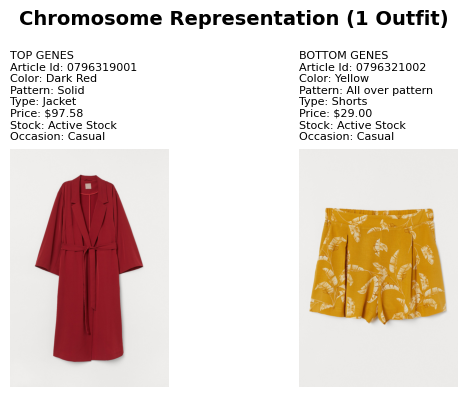

Each gene represents one attribute of a garment.
The chromosome is split into two halves: TOP and BOTTOM.
This structure ensures crossover and mutation operate on
complete garments, preserving attribute coherence.


In [6]:
# --- Population Initialisation ---
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_DIR = "../data/raw/images"

def load_article_image(article_id):
    """Load image for an article ID."""
    aid = str(article_id).zfill(10)
    folder = aid[:3]
    path = os.path.join(IMAGE_DIR, folder, f"{aid}.jpg")
    try:
        return Image.open(path)
    except FileNotFoundError:
        return None

candidate_pool = candidate_df.to_dict("records")

# Dynamic population sizing
pop_size = max(POPULATION_SIZE, NUM_OUTFITS * 30)
pop_size = min(pop_size, len(candidate_pool))

# Random sampling (with replacement) from the candidate pool
population = random.choices(candidate_pool, k=pop_size)

print(f"Candidate pool size: {len(candidate_pool)} pairs")
print(f"Population size:     {pop_size} individuals")

# ============================================================
# CHROMOSOME & GENE STRUCTURE (with images)
# ============================================================
sample = population[0]

fig, axes = plt.subplots(1, 2, figsize=(6, 4))
fig.suptitle("Chromosome Representation (1 Outfit)", fontsize=14, fontweight="bold")

# Top image
top_img = load_article_image(sample.get("Top_Article"))
if top_img:
    axes[0].imshow(top_img)
axes[0].set_title(
    f"TOP GENES\n"
    f"Article Id: {sample.get('Top_Article','?')}\n"
    f"Color: {sample.get('Top_Color','?')}\n"
    f"Pattern: {sample.get('Top_Pattern','?')}\n"
    f"Type: {sample.get('Top_Type','?')}\n"
    f"Price: ${sample.get('Top_Price',0):.2f}\n"
    f"Stock: {sample.get('Top_Stock_Status','?')}\n"
    f"Occasion: {sample.get('Top_Occasion','?')}",
    fontsize=8, loc="left")
axes[0].axis("off")

# Bottom image
bot_img = load_article_image(sample.get("Bottom_Article"))
if bot_img:
    axes[1].imshow(bot_img)
axes[1].set_title(
    f"BOTTOM GENES\n"
    f"Article Id: {sample.get('Bottom_Article','?')}\n"
    f"Color: {sample.get('Bottom_Color','?')}\n"
    f"Pattern: {sample.get('Bottom_Pattern','?')}\n"
    f"Type: {sample.get('Bottom_Type','?')}\n"
    f"Price: ${sample.get('Bottom_Price',0):.2f}\n"
    f"Stock: {sample.get('Bottom_Stock_Status','?')}\n"
    f"Occasion: {sample.get('Bottom_Occasion','?')}",
    fontsize=8, loc="left")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Each gene represents one attribute of a garment.")
print("The chromosome is split into two halves: TOP and BOTTOM.")
print("This structure ensures crossover and mutation operate on")
print("complete garments, preserving attribute coherence.")

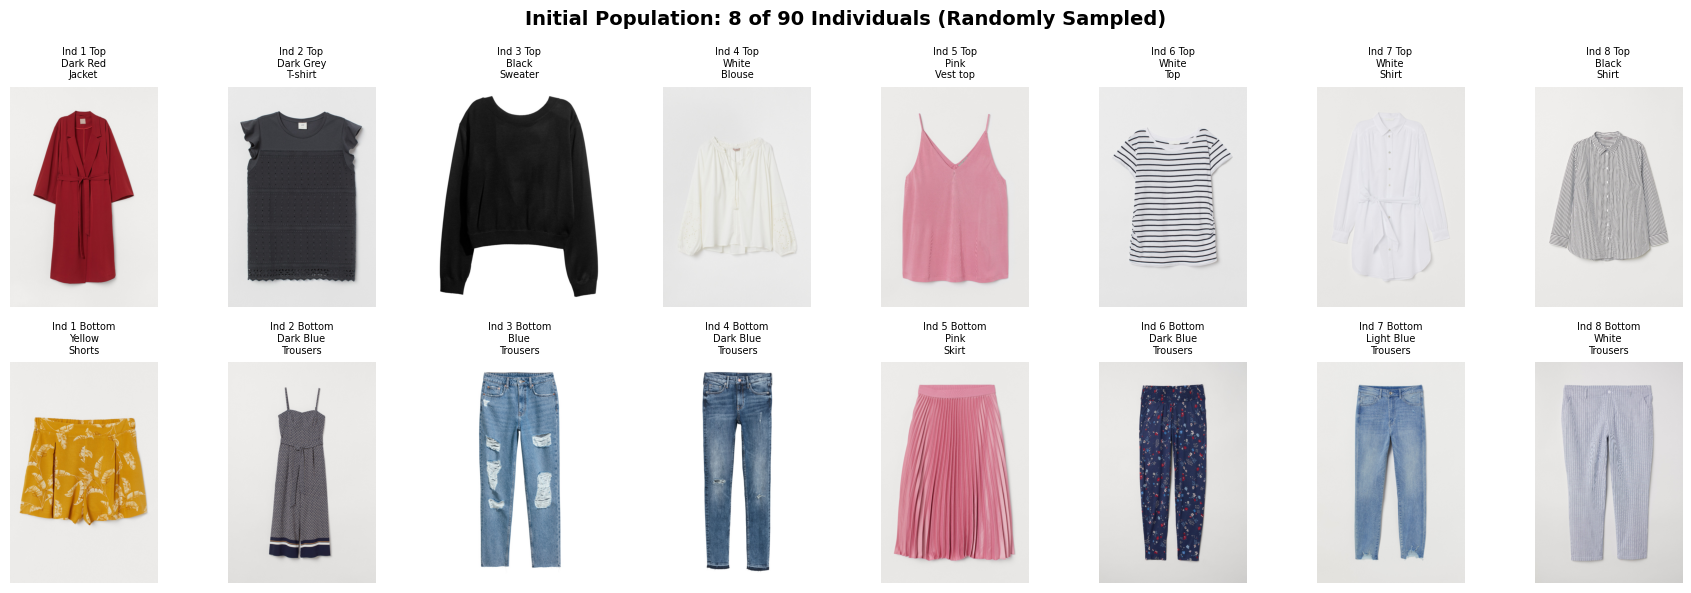


Showing 8 of 90 individuals in the initial population.
Each column is one chromosome (outfit). Row 1 = top genes, Row 2 = bottom genes.
Notice the DIVERSITY: different colours, types, and patterns across individuals.
This diversity is crucial for the GA to explore the solution space effectively.


In [7]:
# ============================================================
# INITIAL POPULATION OVERVIEW (first 8 individuals)
# ============================================================
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_DIR = "../data/raw/images"

def load_article_image(article_id):
    """Load image for an article ID."""
    aid = str(article_id).zfill(10)
    folder = aid[:3]
    path = os.path.join(IMAGE_DIR, folder, f"{aid}.jpg")
    try:
        return Image.open(path)
    except FileNotFoundError:
        return None

num_show = min(8, len(population))
fig, axes = plt.subplots(2, num_show, figsize=(2.2 * num_show, 6))
fig.suptitle(f"Initial Population: {num_show} of {pop_size} Individuals (Randomly Sampled)", fontsize=14, fontweight="bold")

for i in range(num_show):
    ind = population[i]

    # Top image (row 0)
    top_img = load_article_image(ind.get("Top_Article"))
    if top_img:
        axes[0][i].imshow(top_img)
    axes[0][i].set_title(f"Ind {i+1} Top\n{ind.get('Top_Color','?')}\n{ind.get('Top_Type','?')}", fontsize=7)
    axes[0][i].axis("off")

    # Bottom image (row 1)
    bot_img = load_article_image(ind.get("Bottom_Article"))
    if bot_img:
        axes[1][i].imshow(bot_img)
    axes[1][i].set_title(f"Ind {i+1} Bottom\n{ind.get('Bottom_Color','?')}\n{ind.get('Bottom_Type','?')}", fontsize=7)
    axes[1][i].axis("off")

axes[0][0].set_ylabel("TOP", fontsize=11, fontweight="bold")
axes[1][0].set_ylabel("BOTTOM", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nShowing {num_show} of {pop_size} individuals in the initial population.")
print("Each column is one chromosome (outfit). Row 1 = top genes, Row 2 = bottom genes.")
print("Notice the DIVERSITY: different colours, types, and patterns across individuals.")
print("This diversity is crucial for the GA to explore the solution space effectively.")

In [8]:
# ============================================================
# INITIAL POPULATION TABLE VIEW
# ============================================================
print("INITIAL POPULATION - Table View (first 10 individuals)")
print("=" * 100)

display_cols = ["Top_Color", "Top_Type", "Top_Pattern", "Top_Price",
                "Bottom_Color", "Bottom_Type", "Bottom_Pattern", "Bottom_Price"]

sample_pop_df = pd.DataFrame(population[:10])
available_cols = [c for c in display_cols if c in sample_pop_df.columns]
sample_pop_df.index = [f"Ind {i+1}" for i in range(len(sample_pop_df))]
sample_pop_df[available_cols]

INITIAL POPULATION - Table View (first 10 individuals)


,Top_Color,Top_Type,Top_Pattern,Top_Price,Bottom_Color,Bottom_Type,Bottom_Pattern,Bottom_Price
Ind 1,Dark Red,Jacket,Solid,97.58,Yellow,Shorts,All over pattern,29.00
Ind 2,Dark Grey,T-shirt,Solid,28.19,Dark Blue,Trousers,All over pattern,82.73
Ind 3,Black,Sweater,Solid,20.57,Blue,Trousers,Solid,37.55
Ind 4,White,Blouse,Solid,57.66,Dark Blue,Trousers,Denim,33.38
Ind 5,Pink,Vest top,Solid,26.30,Pink,Skirt,Solid,63.66
Ind 6,White,Top,Stripe,14.29,Dark Blue,Trousers,All over pattern,22.80
Ind 7,White,Shirt,Solid,56.42,Light Blue,Trousers,Denim,51.89
Ind 8,Black,Shirt,All over pattern,25.49,White,Trousers,Stripe,30.57
Ind 9,Black,Jacket,Solid,43.27,White,Shorts,All over pattern,18.11
Ind 10,Dark Orange,Vest top,Sequin,18.08,Dark Pink,Skirt,Embroidery,83.53


### Chromosome Representation

Each individual is a **dictionary** with paired attributes for the top and bottom garments:

```
{
  Top_Article:  "0856789001"     Bottom_Article:  "0432156001"
  Top_Color:    "Black"          Bottom_Color:    "Blue"
  Top_Pattern:  "Solid"          Bottom_Pattern:  "Solid"
  Top_Type:     "T-shirt"        Bottom_Type:     "Jeans"
  Top_Price:    19.99            Bottom_Price:     39.99
  Top_Stock:    "Active"         Bottom_Stock:    "Dead Stock"
}
```

This **paired-gene** structure is important because:
- Crossover swaps entire halves (top or bottom), preserving intra-garment coherence
- You never get a nonsensical mix like "top's colour with bottom's price"

---
## 4. Fitness Function

### Formula
```
f(x) = W1 * color_lift + W2 * pattern_lift + W3 * type_lift + W4 * dead_stock_bonus - W5 * price_penalty + W6 * budget_utilisation
```

### Components
| # | Component | Weight | Range | Purpose |
|---|-----------|--------|-------|--------|
| 1 | Color Lift | 0.30 | [0, 1] | How well the colours match (from purchase data) |
| 2 | Pattern Lift | 0.20 | [0, 1] | How well the patterns match |
| 3 | Type Lift | 0.20 | [0, 1] | How well the garment types match |
| 4 | Dead Stock Bonus | 0.20 | {0, 0.5, 1.0} | Incentivise clearing slow-moving inventory |
| 5 | Price Penalty | 0.10 | [0, inf) | Penalise outfits exceeding budget (**subtracted**) |
| 6 | Budget Utilisation | 0.15 | [0, 1] | Reward spending closer to budget (no waste) |

### Why this matters
The fitness function is the **heart of the GA** â€” it defines what a "good" outfit means.

**Without the fitness function**, the GA has no way to distinguish good solutions from bad ones, and evolution would be random drift.

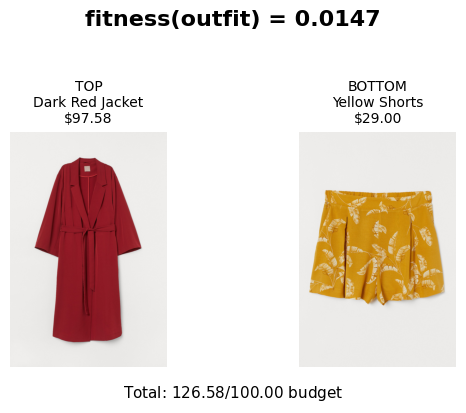

In [9]:
def fitness(candidate, max_price):
    """Evaluate fitness of a single candidate (top-bottom pair)."""
    color_score = color_lift.get((candidate["Top_Color"], candidate["Bottom_Color"]), 0.0)
    pattern_score = pattern_lift.get((candidate["Top_Pattern"], candidate["Bottom_Pattern"]), 0.0)
    type_score = type_lift.get((candidate.get("Top_Type", ""), candidate.get("Bottom_Type", "")), 0.0)

    top_dead = candidate.get("Top_Stock_Status", "") == "Dead Stock"
    bottom_dead = candidate.get("Bottom_Stock_Status", "") == "Dead Stock"
    if top_dead and bottom_dead:
        dead_bonus = DEAD_STOCK_BONUS_BOTH
    elif top_dead or bottom_dead:
        dead_bonus = DEAD_STOCK_BONUS_SINGLE
    else:
        dead_bonus = 0.0

    total_price = (candidate.get("Top_Price", 0.0) or 0.0) + (candidate.get("Bottom_Price", 0.0) or 0.0)
    if total_price > max_price:
        price_pen = (total_price - max_price) / max_price
        budget_util = 0.0
    else:
        price_pen = 0.0
        budget_util = min(total_price / max_price, 1.0) if max_price > 0 else 0.0

    score = (W1 * color_score + W2 * pattern_score + W3 * type_score
             + W4 * dead_bonus - W5 * price_pen + W6 * budget_util)

    return score, {
        "color_score": round(color_score, 4),
        "pattern_score": round(pattern_score, 4),
        "type_score": round(type_score, 4),
        "dead_bonus": dead_bonus,
        "price_pen": round(price_pen, 4),
        "budget_util": round(budget_util, 4),
        "total_fitness": round(score, 4)
    }

# --- Simple Fitness Display: Outfit + Score ---
ind = population[0]
score, bd = fitness(ind, MAX_PRICE)
total_price = (ind.get('Top_Price', 0) or 0) + (ind.get('Bottom_Price', 0) or 0)

fig, axes = plt.subplots(1, 2, figsize=(6, 4))
fig.suptitle(f"fitness(outfit) = {bd['total_fitness']:.4f}", fontsize=16, fontweight="bold")

# Top image
top_img = load_article_image(ind.get("Top_Article"))
if top_img:
    axes[0].imshow(top_img)
axes[0].set_title(
    f"TOP\n"
    f"{ind.get('Top_Color','?')} {ind.get('Top_Type','?')}\n"
    f"${ind.get('Top_Price',0):.2f}",
    fontsize=10)
axes[0].axis("off")

# Bottom image
bot_img = load_article_image(ind.get("Bottom_Article"))
if bot_img:
    axes[1].imshow(bot_img)
axes[1].set_title(
    f"BOTTOM\n"
    f"{ind.get('Bottom_Color','?')} {ind.get('Bottom_Type','?')}\n"
    f"${ind.get('Bottom_Price',0):.2f}",
    fontsize=10)
axes[1].axis("off")

fig.text(0.5, 0.01, f"Total: ${total_price:.2f} / ${MAX_PRICE:.2f} budget", ha="center", fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.show()

In [10]:
# --- Distribution of fitness scores across the initial population ---
initial_scores = [fitness(ind, MAX_PRICE)[0] for ind in population]

print("INITIAL POPULATION FITNESS STATISTICS")
print(f"  Min fitness:    {min(initial_scores):.4f}")
print(f"  Max fitness:    {max(initial_scores):.4f}")
print(f"  Mean fitness:   {np.mean(initial_scores):.4f}")
print(f"  Std deviation:  {np.std(initial_scores):.4f}")
print()
print("This spread shows the diversity in the initial population.")
print("The GA will try to push the population toward higher fitness over generations.")

INITIAL POPULATION FITNESS STATISTICS
  Min fitness:    0.0147
  Max fitness:    0.3040
  Mean fitness:   0.1505
  Std deviation:  0.0670

This spread shows the diversity in the initial population.
The GA will try to push the population toward higher fitness over generations.


---
## 5. Selection â€” Tournament Selection (k=3)

### How it works
1. Randomly pick **3 individuals** from the population
2. Select the one with the **highest fitness** as a parent
3. Repeat to get a second parent

### Why Tournament Selection?
- **Balances exploration vs exploitation**: better individuals are more likely to be selected, but weaker ones still have a chance
- **Tournament size controls selection pressure**: k=3 provides moderate pressure
  - k=1 would be random selection (no pressure, too slow to converge)
  - k=N (whole population) would always pick the best (too greedy, loses diversity)

### What if we didn't do selection?
- Without selection pressure, evolution becomes **random drift**
- Good solutions would be no more likely to reproduce than bad ones
- The population would never improve

In [11]:
def tournament_select(population, fitnesses):
    """Select one individual via tournament selection (k=3)."""
    indices = random.sample(range(len(population)), min(TOURNAMENT_SIZE, len(population)))
    best_idx = max(indices, key=lambda i: fitnesses[i])
    return population[best_idx].copy()

# --- Demonstrate tournament selection ---
fitnesses = [fitness(ind, MAX_PRICE)[0] for ind in population]

print("=" * 60)
print("TOURNAMENT SELECTION DEMO")
print("=" * 60)

for trial in range(3):
    # Show the tournament
    indices = random.sample(range(len(population)), TOURNAMENT_SIZE)
    print(f"\nTournament {trial+1}: Randomly picked indices {indices}")
    for idx in indices:
        ind = population[idx]
        print(f"  Index {idx}: fitness={fitnesses[idx]:.4f} | {ind.get('Top_Color','?')} {ind.get('Top_Type','?')} + {ind.get('Bottom_Color','?')} {ind.get('Bottom_Type','?')}")

    winner_idx = max(indices, key=lambda i: fitnesses[i])
    print(f"  >> WINNER: Index {winner_idx} (fitness = {fitnesses[winner_idx]:.4f})")

TOURNAMENT SELECTION DEMO

Tournament 1: Randomly picked indices [53, 24, 45]
  Index 53: fitness=0.1749 | Black Sweater + Pink Trousers
  Index 24: fitness=0.1612 | Light Pink Sweater + Greenish Khaki Leggings/Tights
  Index 45: fitness=0.2044 | Black Blouse + Black Skirt
  >> WINNER: Index 45 (fitness = 0.2044)

Tournament 2: Randomly picked indices [55, 66, 88]
  Index 55: fitness=0.1641 | Yellow Shirt + White Trousers
  Index 66: fitness=0.2145 | Light Pink Blouse + Grey Trousers
  Index 88: fitness=0.2555 | Yellow Vest top + Blue Skirt
  >> WINNER: Index 88 (fitness = 0.2555)

Tournament 3: Randomly picked indices [9, 43, 41]
  Index 9: fitness=0.0839 | Dark Orange Vest top + Dark Pink Skirt
  Index 43: fitness=0.0600 | Dark Red Blazer + Light Beige Trousers
  Index 41: fitness=0.1712 | Black Blouse + Black Skirt
  >> WINNER: Index 41 (fitness = 0.1712)


---
## 6. Crossover â€” Swap Top or Bottom

### How it works
Given two parents, crossover creates two children by **swapping either all top genes or all bottom genes** between them.

```
Parent 1: [Red T-shirt,  Blue Jeans]      Parent 2: [Black Hoodie, Grey Trousers]
                          | swap tops |
Child 1:  [Black Hoodie, Blue Jeans]       Child 2:  [Red T-shirt,  Grey Trousers]
```

### Key design choice: Semantic crossover
- We swap **entire garment blocks**, not individual attributes
- This preserves **coherence** â€” a top's colour always stays with its pattern, price, and type
- Without this, we'd get nonsensical combinations (e.g., a Red pattern with Blue price)

### Crossover rate: 70%
- 70% of the time, children are recombinations of parents
- 30% of the time, parents pass through unchanged (children = clones of parents)

### What if we didn't do crossover?
- The GA could only explore the search space through mutation (slow)
- We'd lose the ability to **combine good traits** from two different solutions
- E.g., if one outfit has a great top and another has a great bottom, crossover combines them

CROSSOVER DEMO  |  Swapped: TOPS


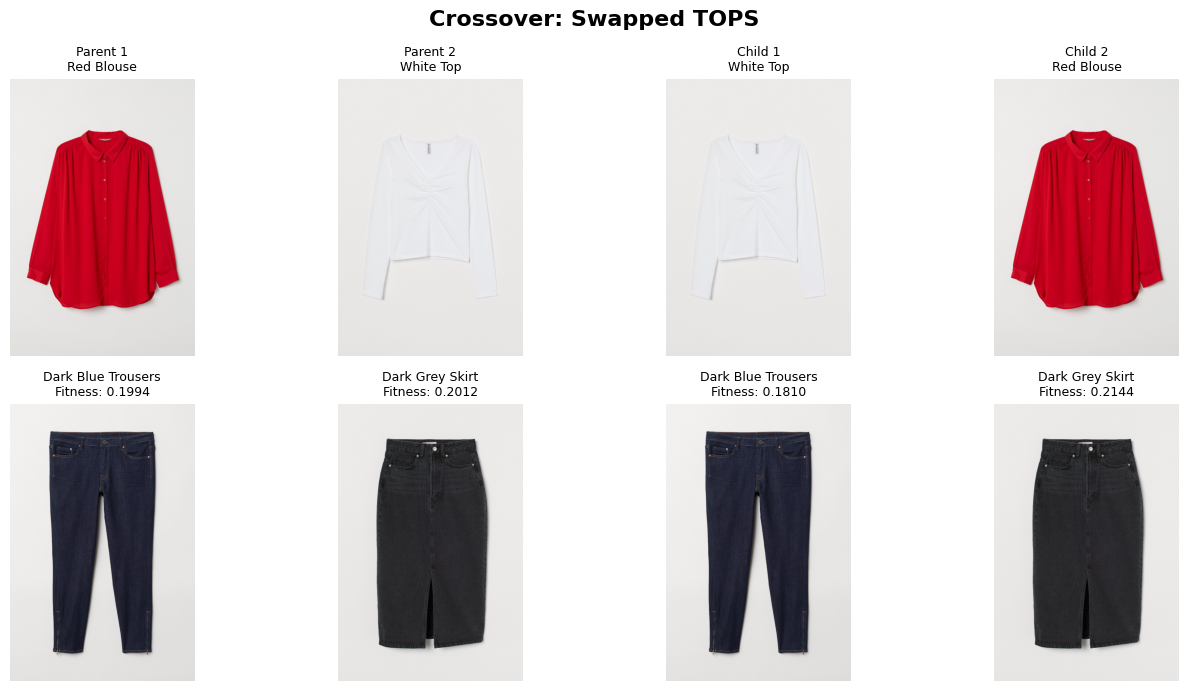

A child has HIGHER fitness than both parents! Crossover found a better combination.


In [12]:
TOP_COLS = ["Top_Article", "Top_Price", "Top_Color", "Top_Pattern", "Top_Stock_Status", "Top_Type", "Top_Occasion"]
BOTTOM_COLS = ["Bottom_Article", "Bottom_Price", "Bottom_Color", "Bottom_Pattern", "Bottom_Stock_Status", "Bottom_Type", "Bottom_Occasion"]

from PIL import Image
import matplotlib.pyplot as plt

IMAGE_DIR = "../data/raw/images"

def load_article_image(article_id):
    """Load image for an article ID. Images stored as images/{first3digits}/{article_id}.jpg"""
    aid = str(article_id).zfill(10)
    folder = aid[:3]
    path = os.path.join(IMAGE_DIR, folder, f"{aid}.jpg")
    try:
        return Image.open(path)
    except FileNotFoundError:
        return None

def crossover(parent1, parent2):
    """Swap top or bottom between two parents."""
    child1, child2 = parent1.copy(), parent2.copy()
    if random.random() < 0.5:
        for col in TOP_COLS:
            child1[col], child2[col] = child2.get(col), child1.get(col)
        swap_type = "TOPS"
    else:
        for col in BOTTOM_COLS:
            child1[col], child2[col] = child2.get(col), child1.get(col)
        swap_type = "BOTTOMS"
    return child1, child2, swap_type

# --- Demonstrate crossover with images ---
parent1 = tournament_select(population, fitnesses)
parent2 = tournament_select(population, fitnesses)
child1, child2, swap_type = crossover(parent1, parent2)

p1_score = fitness(parent1, MAX_PRICE)[0]
p2_score = fitness(parent2, MAX_PRICE)[0]
c1_score = fitness(child1, MAX_PRICE)[0]
c2_score = fitness(child2, MAX_PRICE)[0]

print("=" * 60)
print(f"CROSSOVER DEMO  |  Swapped: {swap_type}")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(f"Crossover: Swapped {swap_type}", fontsize=16, fontweight="bold")

for col_idx, (label, ind, score) in enumerate([
    ("Parent 1", parent1, p1_score), ("Parent 2", parent2, p2_score),
    ("Child 1", child1, c1_score), ("Child 2", child2, c2_score)
]):
    # Top image
    top_img = load_article_image(ind.get("Top_Article"))
    if top_img:
        axes[0][col_idx].imshow(top_img)
    axes[0][col_idx].set_title(f"{label}\n{ind.get('Top_Color','?')} {ind.get('Top_Type','?')}", fontsize=9)
    axes[0][col_idx].axis("off")
    if col_idx == 0:
        axes[0][col_idx].set_ylabel("TOP", fontsize=12, fontweight="bold")

    # Bottom image
    bot_img = load_article_image(ind.get("Bottom_Article"))
    if bot_img:
        axes[1][col_idx].imshow(bot_img)
    axes[1][col_idx].set_title(f"{ind.get('Bottom_Color','?')} {ind.get('Bottom_Type','?')}\nFitness: {score:.4f}", fontsize=9)
    axes[1][col_idx].axis("off")
    if col_idx == 0:
        axes[1][col_idx].set_ylabel("BOTTOM", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

if c1_score > max(p1_score, p2_score) or c2_score > max(p1_score, p2_score):
    print("A child has HIGHER fitness than both parents! Crossover found a better combination.")
else:
    print("Children fitness varies. Not every crossover improves, but it explores new combinations.")

---
## 7. Mutation â€” Replace from Candidate Pool

### How it works
With 20% probability, an individual's **top or bottom half** is replaced with a random donor from the **original candidate pool**.

### Why mutate from the original pool (not random values)?
- Ensures mutations produce **valid garments** that actually exist in the inventory
- Reintroduces **genetic diversity** that may have been lost during selection
- Without mutation, the GA can **converge prematurely** (get stuck in a local optimum)

### What if we didn't do mutation?
- The population would become increasingly homogeneous over generations
- Once diversity is lost, crossover between similar parents produces similar children
- The GA gets **trapped in a local optimum** â€” it finds a "good enough" solution but misses the global best
- Mutation is the GA's mechanism for **exploration** vs crossover's **exploitation**

MUTATION DEMO  |  Mutated: TOP


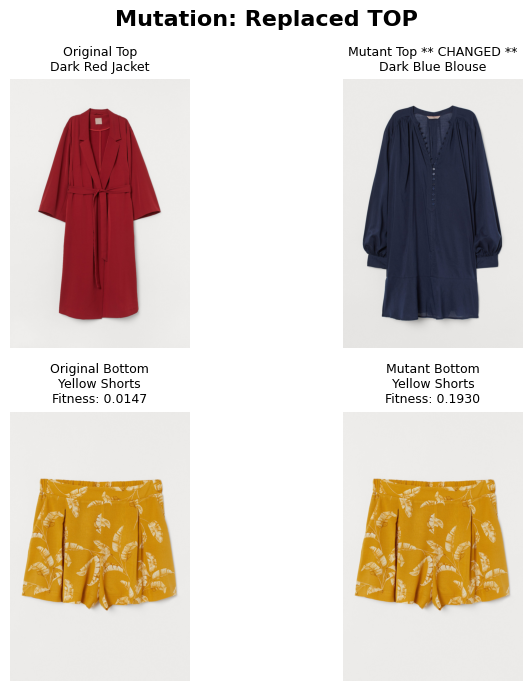


Fitness change: 0.0147 -> 0.1930 (improved)

Note: Mutation can worsen fitness in the short term, but it prevents
the population from getting stuck in a local optimum.


In [13]:
def mutate(individual, candidate_pool):
    """Replace top or bottom with a random candidate from the pool."""
    donor = random.choice(candidate_pool)
    mutant = individual.copy()
    if random.random() < 0.5:
        for col in TOP_COLS:
            mutant[col] = donor.get(col)
        mutated_part = "TOP"
    else:
        for col in BOTTOM_COLS:
            mutant[col] = donor.get(col)
        mutated_part = "BOTTOM"
    return mutant, mutated_part

# --- Demonstrate mutation with images ---
original = population[0].copy()
mutant, mutated_part = mutate(original, candidate_pool)

orig_score = fitness(original, MAX_PRICE)[0]
mut_score = fitness(mutant, MAX_PRICE)[0]

print("=" * 60)
print(f"MUTATION DEMO  |  Mutated: {mutated_part}")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
fig.suptitle(f"Mutation: Replaced {mutated_part}", fontsize=16, fontweight="bold")

for col_idx, (label, ind, score) in enumerate([
    ("Original", original, orig_score), ("Mutant", mutant, mut_score)
]):
    top_img = load_article_image(ind.get("Top_Article"))
    if top_img:
        axes[0][col_idx].imshow(top_img)
    highlight = " ** CHANGED **" if (mutated_part == "TOP" and col_idx == 1) else ""
    axes[0][col_idx].set_title(f"{label} Top{highlight}\n{ind.get('Top_Color','?')} {ind.get('Top_Type','?')}", fontsize=9)
    axes[0][col_idx].axis("off")

    bot_img = load_article_image(ind.get("Bottom_Article"))
    if bot_img:
        axes[1][col_idx].imshow(bot_img)
    highlight = " ** CHANGED **" if (mutated_part == "BOTTOM" and col_idx == 1) else ""
    axes[1][col_idx].set_title(f"{label} Bottom{highlight}\n{ind.get('Bottom_Color','?')} {ind.get('Bottom_Type','?')}\nFitness: {score:.4f}", fontsize=9)
    axes[1][col_idx].axis("off")

plt.tight_layout()
plt.show()

print(f"\nFitness change: {orig_score:.4f} -> {mut_score:.4f} ({'improved' if mut_score > orig_score else 'worsened' if mut_score < orig_score else 'same'})")
print("\nNote: Mutation can worsen fitness in the short term, but it prevents")
print("the population from getting stuck in a local optimum.")

---
## 8. Elitism â€” Preserve the Best

### How it works
Before creating the next generation, we **copy the single best individual** directly into the new population.

### Why elitism?
- **Guarantees monotonic improvement**: the best fitness never decreases across generations
- Without elitism, the best solution found so far could be **lost** through crossover or mutation
- Acts as a safety net â€” even if a generation produces poor offspring, the best is preserved

### What if we didn't do elitism?
- The best solution from generation N might not survive to generation N+1
- Fitness could **oscillate** â€” sometimes improving, sometimes degrading
- We'd risk losing our best discoveries

In [14]:
# --- Demonstrate Elitism ---
fitnesses = [fitness(ind, MAX_PRICE)[0] for ind in population]

# Find the best individual (the elite)
best_idx = max(range(len(population)), key=lambda i: fitnesses[i])
elite = population[best_idx].copy()
elite_score = fitnesses[best_idx]

print("=" * 60)
print("ELITISM DEMO")
print("=" * 60)
print(f"\nPopulation size: {len(population)}")
print(f"Best individual index: {best_idx}")
print(f"Best fitness: {elite_score:.4f}")
print(f"Best outfit: {elite.get('Top_Color','?')} {elite.get('Top_Type','?')} + {elite.get('Bottom_Color','?')} {elite.get('Bottom_Type','?')}")
print(f"\nThis individual is GUARANTEED to survive to the next generation.")
print(f"The remaining {pop_size - 1} slots are filled by selection + crossover + mutation.")
print()
print(f"Mean fitness:   {np.mean(fitnesses):.4f}")
print(f"Elite fitness:  {elite_score:.4f}")
print(f"Gap:            {elite_score - np.mean(fitnesses):.4f} (elite is this much better than average)")

ELITISM DEMO

Population size: 90
Best individual index: 49
Best fitness: 0.3040
Best outfit: Light Grey Jacket + Light Grey Trousers

This individual is GUARANTEED to survive to the next generation.
The remaining 89 slots are filled by selection + crossover + mutation.

Mean fitness:   0.1505
Elite fitness:  0.3040
Gap:            0.1535 (elite is this much better than average)


---
## 9. Full Evolution Loop & Termination

### Putting it all together
Now we run the complete GA evolution loop for 100 generations:

```
For each generation:
  1. Evaluate fitness of all individuals
  2. Elitism: copy the best to the next generation
  3. Fill the rest via: Tournament Select -> Crossover (70%) -> Mutation (20%)
  4. Replace the population
```

### Termination
We use a **fixed generation count** (100 generations).

### Why fixed termination?
- Simple and predictable runtime
- For a recommendation system, we need consistent response times
- 100 generations is sufficient for the GA to converge on good solutions given our population size

### What if we ran too few generations?
- The GA wouldn't have enough time to converge
- Solutions would be suboptimal â€” similar to a random search

### What if we ran too many?
- Diminishing returns after convergence
- Wastes computation time with no improvement

In [15]:
# --- Full Evolution Loop (with tracking for visualisation) ---

# Re-initialise population
population = random.choices(candidate_pool, k=pop_size)

# Track statistics per generation
gen_best = []
gen_mean = []
gen_worst = []

print("=" * 60)
print("RUNNING FULL GA EVOLUTION")
print("=" * 60)
print(f"Population: {pop_size} | Generations: {GENERATIONS}")
print(f"Crossover: {CROSSOVER_RATE} | Mutation: {MUTATION_RATE} | Tournament: k={TOURNAMENT_SIZE}")
print()

for gen in range(GENERATIONS):
    # Evaluate
    fitnesses = [fitness(ind, MAX_PRICE)[0] for ind in population]

    # Track stats
    gen_best.append(max(fitnesses))
    gen_mean.append(np.mean(fitnesses))
    gen_worst.append(min(fitnesses))

    # Print progress every 10 generations
    if gen % 10 == 0 or gen == GENERATIONS - 1:
        print(f"  Gen {gen:3d}: Best={max(fitnesses):.4f}  Mean={np.mean(fitnesses):.4f}  Worst={min(fitnesses):.4f}")

    # Elitism
    new_population = []
    best_idx = max(range(len(population)), key=lambda i: fitnesses[i])
    new_population.append(population[best_idx].copy())

    # Fill the rest
    while len(new_population) < pop_size:
        parent1 = tournament_select(population, fitnesses)
        parent2 = tournament_select(population, fitnesses)

        if random.random() < CROSSOVER_RATE:
            child1, child2, _ = crossover(parent1, parent2)
        else:
            child1, child2 = parent1, parent2

        if random.random() < MUTATION_RATE:
            child1, _ = mutate(child1, candidate_pool)
        if random.random() < MUTATION_RATE:
            child2, _ = mutate(child2, candidate_pool)

        new_population.append(child1)
        if len(new_population) < pop_size:
            new_population.append(child2)

    population = new_population

print()
print(f"Evolution complete!")
print(f"  Initial best fitness:  {gen_best[0]:.4f}")
print(f"  Final best fitness:    {gen_best[-1]:.4f}")
print(f"  Improvement:           {gen_best[-1] - gen_best[0]:+.4f}")

RUNNING FULL GA EVOLUTION
Population: 90 | Generations: 100
Crossover: 0.7 | Mutation: 0.2 | Tournament: k=3

  Gen   0: Best=0.3129  Mean=0.1439  Worst=-0.0847
  Gen  10: Best=0.3850  Mean=0.3411  Worst=0.1786
  Gen  20: Best=0.4211  Mean=0.3873  Worst=0.1035
  Gen  30: Best=0.4211  Mean=0.3804  Worst=0.0748
  Gen  40: Best=0.4211  Mean=0.3762  Worst=0.0902
  Gen  50: Best=0.4211  Mean=0.3768  Worst=0.1267
  Gen  60: Best=0.4211  Mean=0.3855  Worst=0.0715
  Gen  70: Best=0.4211  Mean=0.3927  Worst=0.1328
  Gen  80: Best=0.4211  Mean=0.3687  Worst=0.1020
  Gen  90: Best=0.4211  Mean=0.3887  Worst=0.1328
  Gen  99: Best=0.4211  Mean=0.3813  Worst=0.1095

Evolution complete!
  Initial best fitness:  0.3129
  Final best fitness:    0.4211
  Improvement:           +0.1082


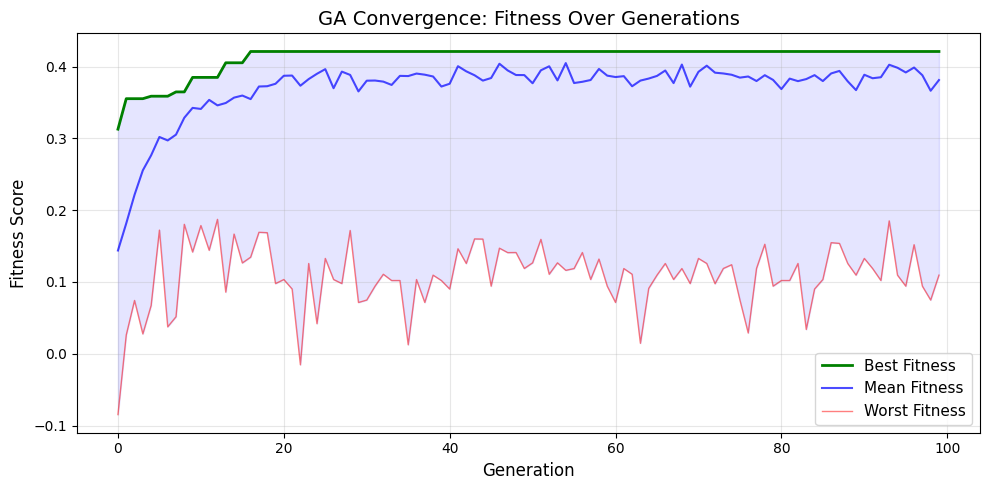


The plot shows:
  - Green (Best): monotonically non-decreasing thanks to ELITISM
  - Blue (Mean): population average improves as better genes spread
  - Red (Worst): stays low due to MUTATION introducing exploration
  - Shaded area: fitness diversity in the population


In [16]:
# --- Convergence Plot ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
gens = range(GENERATIONS)
ax.plot(gens, gen_best, label="Best Fitness", color="green", linewidth=2)
ax.plot(gens, gen_mean, label="Mean Fitness", color="blue", linewidth=1.5, alpha=0.7)
ax.plot(gens, gen_worst, label="Worst Fitness", color="red", linewidth=1, alpha=0.5)
ax.fill_between(gens, gen_worst, gen_best, alpha=0.1, color="blue")

ax.set_xlabel("Generation", fontsize=12)
ax.set_ylabel("Fitness Score", fontsize=12)
ax.set_title("GA Convergence: Fitness Over Generations", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nThe plot shows:")
print("  - Green (Best): monotonically non-decreasing thanks to ELITISM")
print("  - Blue (Mean): population average improves as better genes spread")
print("  - Red (Worst): stays low due to MUTATION introducing exploration")
print("  - Shaded area: fitness diversity in the population")

---
## 10. Diverse Post-Selection (Softmax Sampling)

### The Problem
After evolution, the population may have **converged** â€” many individuals might be the same or very similar outfit. But the user asked for **N different outfits**.

### Our Solution
1. **Merge** the evolved population with the original candidate pool (ensures variety)
2. **Score** all unique (top, bottom) pairs
3. Convert scores to **softmax probabilities** (temperature = 0.1, nearly deterministic)
4. **Sample** outfits weighted by fitness, with the constraint that **no article is reused**

### Why softmax instead of just picking the top N?
- Adds controlled stochasticity â€” the system doesn't always return the exact same outfits
- Temperature controls the trade-off: low temp (0.1) = nearly deterministic, high temp = more random
- This is important for user experience â€” recommendations should feel fresh

In [17]:
# --- Diverse Post-Selection ---

# Merge evolved population with original candidate pool
all_candidates = candidate_pool + population
all_scored = {}
for ind in all_candidates:
    key = (ind.get("Top_Article"), ind.get("Bottom_Article"))
    if key not in all_scored:
        score = fitness(ind, MAX_PRICE)[0]
        all_scored[key] = (ind, score)

print(f"Total unique (top, bottom) pairs scored: {len(all_scored)}")
print()

# Softmax probability calculation
candidates_list = list(all_scored.values())
scores = np.array([s for _, s in candidates_list])

exp_scores = np.exp(scores / max(SELECTION_TEMP, 1e-8))
probabilities = exp_scores / exp_scores.sum()

# Show top 5 candidates by probability
top_indices = np.argsort(probabilities)[::-1][:5]
print("TOP 5 CANDIDATES BY SELECTION PROBABILITY:")
print(f"{'Rank':<5} {'Fitness':<10} {'Probability':<12} {'Top':<25} {'Bottom':<25}")
print("-" * 80)
for rank, idx in enumerate(top_indices, 1):
    ind, score = candidates_list[idx]
    top_desc = f"{ind.get('Top_Color','?')} {ind.get('Top_Type','?')}"
    bot_desc = f"{ind.get('Bottom_Color','?')} {ind.get('Bottom_Type','?')}"
    print(f"{rank:<5} {score:<10.4f} {probabilities[idx]:<12.6f} {top_desc:<25} {bot_desc:<25}")

Total unique (top, bottom) pairs scored: 491

TOP 5 CANDIDATES BY SELECTION PROBABILITY:
Rank  Fitness    Probability  Top                       Bottom                   
--------------------------------------------------------------------------------
1     0.4211     0.021170     Black Sweater             Dark Blue Skirt          
2     0.4161     0.020139     Dark Orange Vest top      Light Turquoise Skirt    
3     0.3965     0.016558     Dark Orange Vest top      Dark Orange Skirt        
4     0.3885     0.015286     Red Shirt                 Light Blue Trousers      
5     0.3309     0.008594     White Top                 Dark Blue Skirt          


FINAL RECOMMENDED OUTFITS (3 outfits)


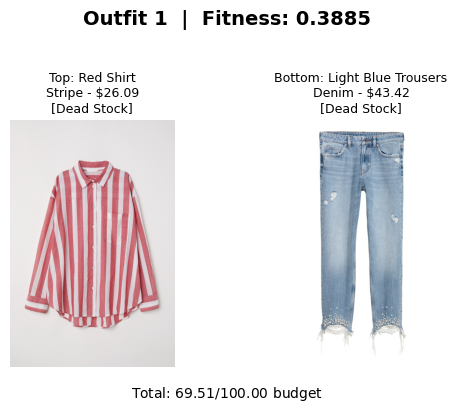

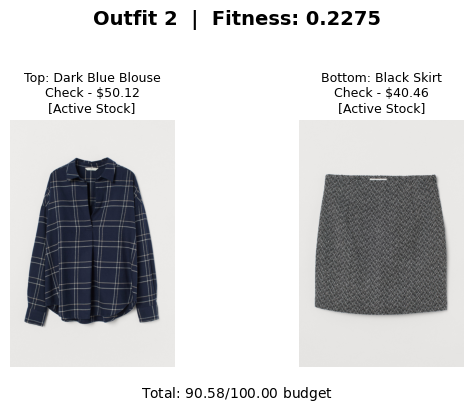

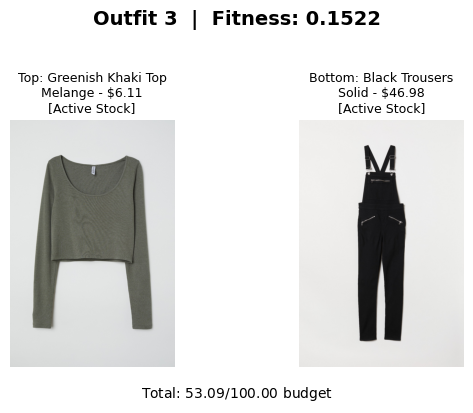


Each outfit uses DIFFERENT articles. No garment is reused across outfits.


In [18]:
# --- Final Selection with No-Reuse Constraint ---
selected = []
used_tops = set()
used_bottoms = set()
remaining_indices = list(range(len(candidates_list)))

while len(selected) < NUM_OUTFITS and remaining_indices:
    remaining_probs = probabilities[remaining_indices]
    prob_sum = remaining_probs.sum()
    if prob_sum == 0:
        break
    remaining_probs = remaining_probs / prob_sum

    idx = np.random.choice(remaining_indices, p=remaining_probs)
    remaining_indices.remove(idx)

    ind, score = candidates_list[idx]
    top_id = ind.get("Top_Article")
    bottom_id = ind.get("Bottom_Article")

    if top_id in used_tops or bottom_id in used_bottoms:
        continue

    result = ind.copy()
    result["fitness_score"] = round(score, 4)
    selected.append(result)
    used_tops.add(top_id)
    used_bottoms.add(bottom_id)

# --- Display Final Results with Images ---
print("=" * 70)
print(f"FINAL RECOMMENDED OUTFITS ({len(selected)} outfits)")
print("=" * 70)

for i, outfit in enumerate(selected):
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))
    fig.suptitle(f"Outfit {i+1}  |  Fitness: {outfit['fitness_score']:.4f}", fontsize=14, fontweight="bold")

    # Top image
    top_img = load_article_image(outfit.get("Top_Article"))
    if top_img:
        axes[0].imshow(top_img)
    axes[0].set_title(f"Top: {outfit.get('Top_Color','?')} {outfit.get('Top_Type','?')}\n"
                      f"{outfit.get('Top_Pattern','?')} - ${outfit.get('Top_Price',0):.2f}\n"
                      f"[{outfit.get('Top_Stock_Status','?')}]", fontsize=9)
    axes[0].axis("off")

    # Bottom image
    bot_img = load_article_image(outfit.get("Bottom_Article"))
    if bot_img:
        axes[1].imshow(bot_img)
    axes[1].set_title(f"Bottom: {outfit.get('Bottom_Color','?')} {outfit.get('Bottom_Type','?')}\n"
                      f"{outfit.get('Bottom_Pattern','?')} - ${outfit.get('Bottom_Price',0):.2f}\n"
                      f"[{outfit.get('Bottom_Stock_Status','?')}]", fontsize=9)
    axes[1].axis("off")

    total = (outfit.get("Top_Price", 0) or 0) + (outfit.get("Bottom_Price", 0) or 0)
    fig.text(0.5, 0.01, f"Total: ${total:.2f} / ${MAX_PRICE:.2f} budget", ha="center", fontsize=10)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

print("\nEach outfit uses DIFFERENT articles. No garment is reused across outfits.")

---
## 11. Summary â€” Why Each Component Matters

| Component | What it does | What happens WITHOUT it |
|-----------|-------------|------------------------|
| **Population Initialisation** | Random sampling from KG candidates | Biased start, gets stuck in local optimum |
| **Fitness Function** | Multi-objective scoring (style + business) | No direction, random drift |
| **Tournament Selection** | Biased reproduction toward fitter individuals | No selection pressure, no improvement |
| **Crossover** | Combines good tops with good bottoms | Slow exploration, can't recombine good traits |
| **Mutation** | Introduces new genetic material from pool | Premature convergence, stuck in local optimum |
| **Elitism** | Preserves the best solution each generation | Best solution can be lost, oscillating fitness |
| **Termination** | Fixed 100 generations | Too few = underfitting, too many = wasted compute |
| **Diverse Selection** | Softmax sampling with no-reuse constraint | Duplicate recommendations, poor user experience |

---
## Virtual Try-On (VTON)
Take the best outfit from the GA and visualise it on a person using **IDM-VTON** (Hugging Face).

In [22]:
# --- VTON Setup ---
from gradio_client import Client as GradioClient, file as gr_file
from PIL import Image

# Pick the best outfit (highest fitness)
best_outfit = max(selected, key=lambda x: x['fitness_score'])
print(f"Best outfit fitness: {best_outfit['fitness_score']}")
print(f"Top: {best_outfit.get('Top_Article')} - {best_outfit.get('Top_Color','')} {best_outfit.get('Top_Type','')}")
print(f"Bottom: {best_outfit.get('Bottom_Article')} - {best_outfit.get('Bottom_Color','')} {best_outfit.get('Bottom_Type','')}")

# Paths
person_path = r'D:\Projects\fashion-recommender\data\input\female.jpg'
top_id = str(best_outfit.get('Top_Article'))
bottom_id = str(best_outfit.get('Bottom_Article'))
top_img_path = os.path.join(IMAGE_DIR, top_id[:3], f'{top_id}.jpg')
bottom_img_path = os.path.join(IMAGE_DIR, bottom_id[:3], f'{bottom_id}.jpg')

# Connect to IDM-VTON
vton_client = GradioClient('yisol/IDM-VTON')
print('Connected to IDM-VTON')


Best outfit fitness: 0.3885
Top: 0632172002 - Red Shirt
Bottom: 0610763001 - Light Blue Trousers
Loaded as API: https://yisol-idm-vton.hf.space
Connected to IDM-VTON


### 1. Try-On: Top Only

Trying on top garment... (this may take a minute)
Done: C:\Users\victo\AppData\Local\Temp\gradio\43b21dfa2e4b340648bcd2e59833c89f4c1df0bdb0e02fa81c82ec122515afc3\image.png


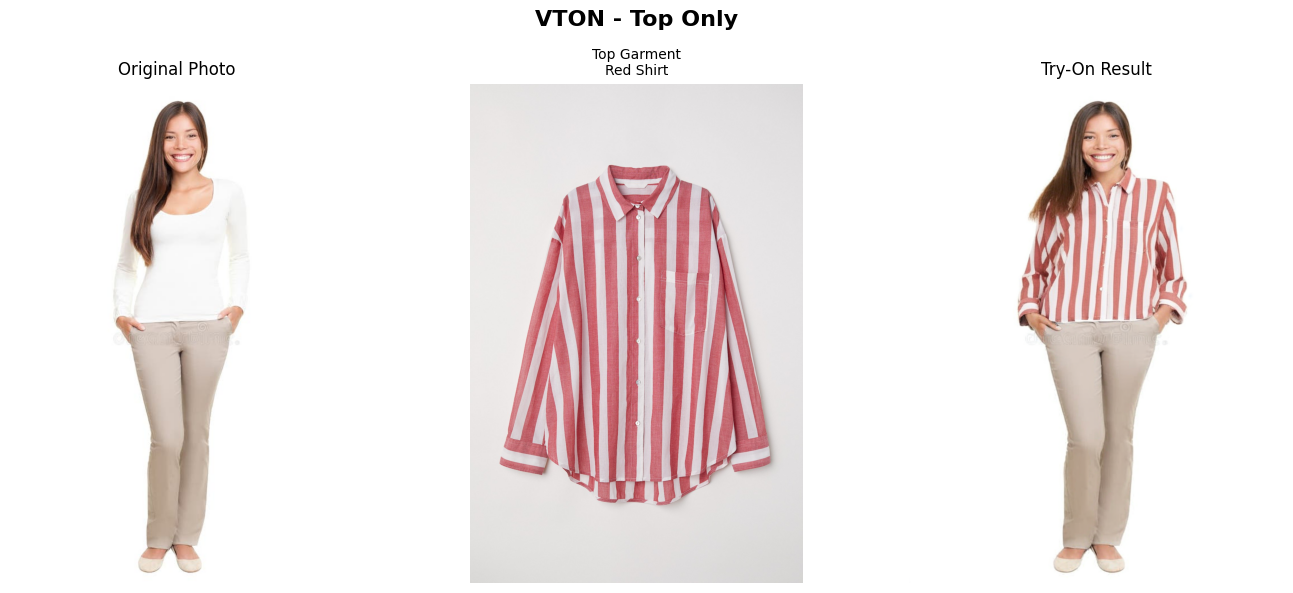

In [23]:
# --- Try on TOP garment only ---
print('Trying on top garment... (this may take a minute)')
top_result = vton_client.predict(
    dict={
        'background': gr_file(person_path),
        'layers': [],
        'composite': None,
    },
    garm_img=gr_file(top_img_path),
    garment_des=f"{best_outfit.get('Top_Color','')} {best_outfit.get('Top_Type','')} top",
    is_checked=True,
    is_checked_crop=False,
    denoise_steps=30,
    seed=42,
    api_name='/tryon',
)
top_result_path = top_result[0]
print(f'Done: {top_result_path}')

# Display
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('VTON - Top Only', fontsize=16, fontweight='bold')

axes[0].imshow(Image.open(person_path))
axes[0].set_title('Original Photo', fontsize=12)
axes[0].axis('off')

axes[1].imshow(Image.open(top_img_path))
axes[1].set_title(f"Top Garment\n{best_outfit.get('Top_Color','')} {best_outfit.get('Top_Type','')}", fontsize=10)
axes[1].axis('off')

axes[2].imshow(Image.open(top_result_path))
axes[2].set_title('Try-On Result', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()


### 2. Try-On: Bottom Only

Trying on bottom garment... (this may take a minute)
Done: C:\Users\victo\AppData\Local\Temp\gradio\a425d6405d01a26a35bf79cee5172656e913a5ad1a000816d992002b56f5c343\image.png


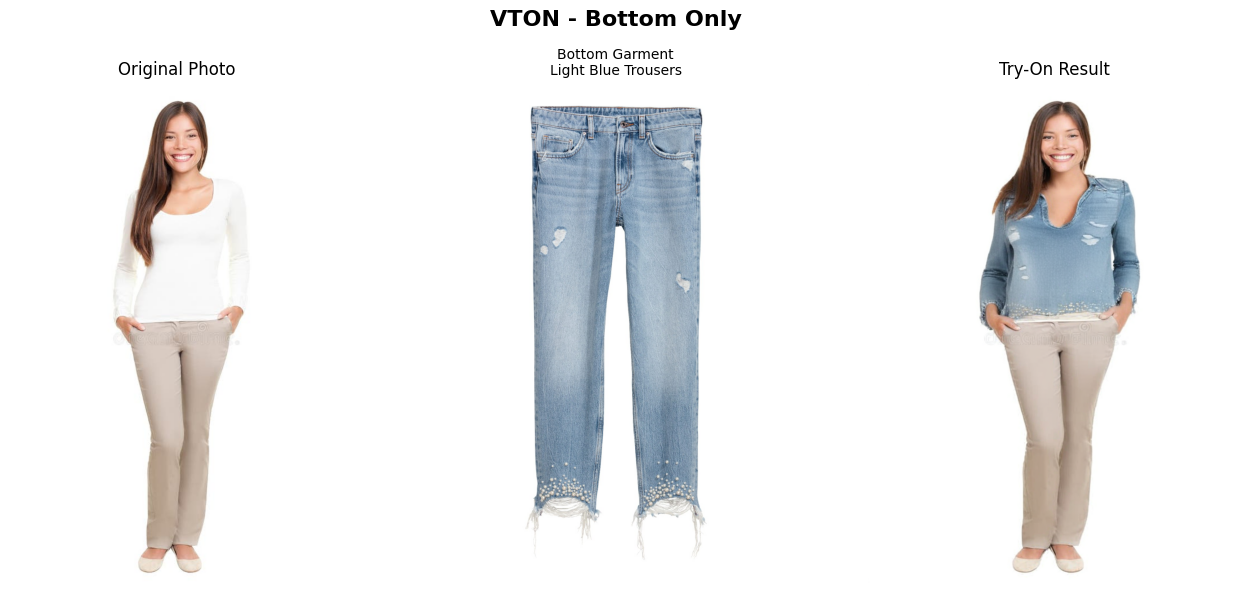

In [24]:
# --- Try on BOTTOM garment only ---
print('Trying on bottom garment... (this may take a minute)')
bottom_only_result = vton_client.predict(
    dict={
        'background': gr_file(person_path),
        'layers': [],
        'composite': None,
    },
    garm_img=gr_file(bottom_img_path),
    garment_des=f"{best_outfit.get('Bottom_Color','')} {best_outfit.get('Bottom_Type','')} bottom",
    is_checked=True,
    is_checked_crop=False,
    denoise_steps=30,
    seed=42,
    api_name='/tryon',
)
bottom_only_result_path = bottom_only_result[0]
print(f'Done: {bottom_only_result_path}')

# Display
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle('VTON - Bottom Only', fontsize=16, fontweight='bold')

axes[0].imshow(Image.open(person_path))
axes[0].set_title('Original Photo', fontsize=12)
axes[0].axis('off')

axes[1].imshow(Image.open(bottom_img_path))
axes[1].set_title(f"Bottom Garment\n{best_outfit.get('Bottom_Color','')} {best_outfit.get('Bottom_Type','')}", fontsize=10)
axes[1].axis('off')

axes[2].imshow(Image.open(bottom_only_result_path))
axes[2].set_title('Try-On Result', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()


### 3. Try-On: Full Outfit (Top then Bottom)

Step 1: Trying on top garment...
Top done: C:\Users\victo\AppData\Local\Temp\gradio\8ec69cfda0f99ba86531f9c65a22b0c7b94ea195d02326e1c10882363711231c\image.png
Step 2: Trying on bottom garment on top result...
Full outfit done: C:\Users\victo\AppData\Local\Temp\gradio\d619a31d5ba7f29b5ec3519feb6cf80958a5dc187e2f962f361a5c8e16eacbd0\image.png


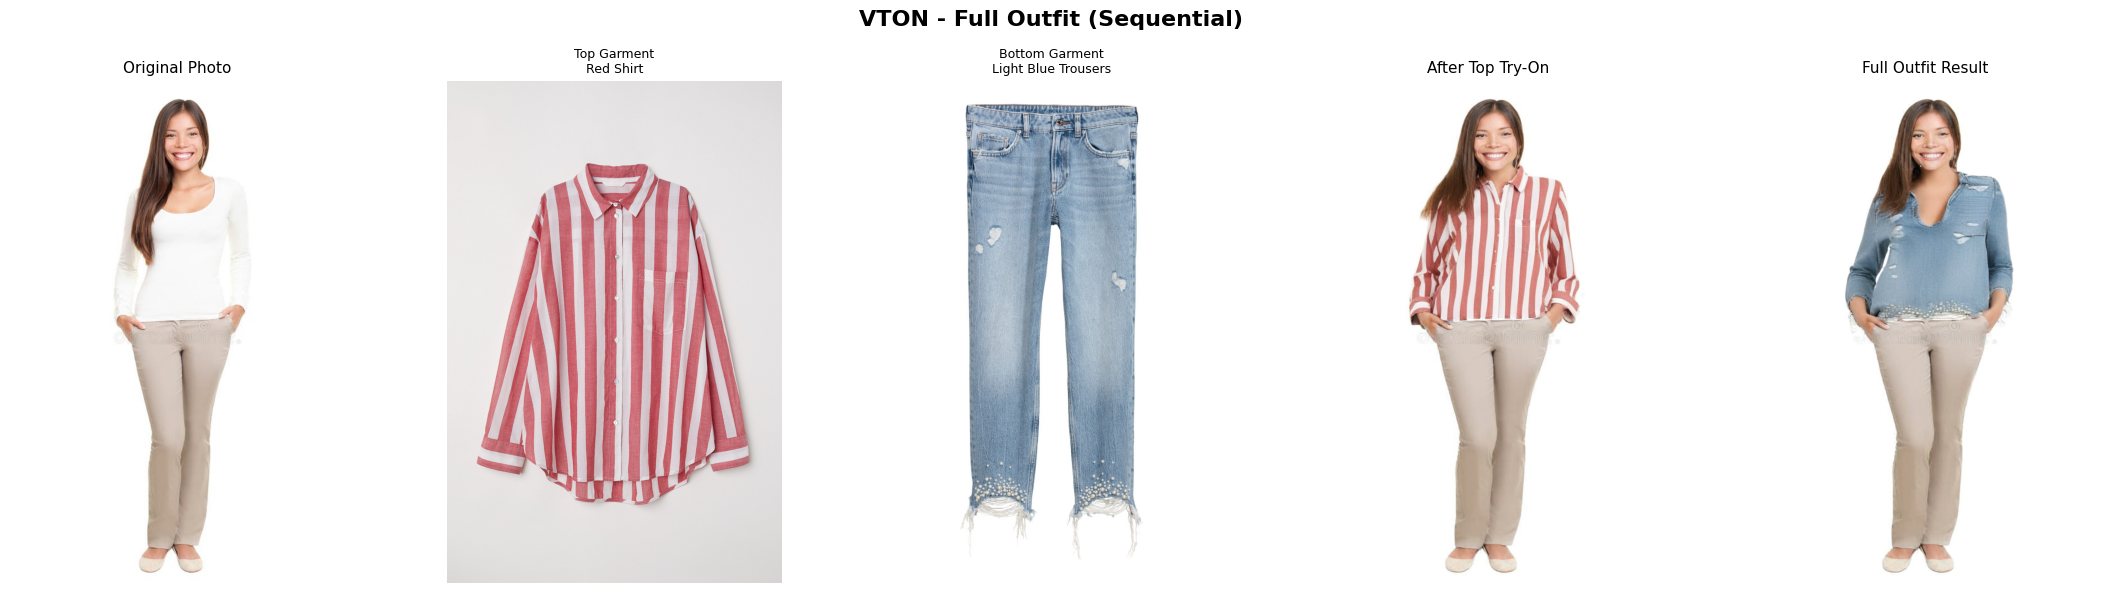

In [25]:
# --- Try on BOTH: Top first, then Bottom on the top result ---
print('Step 1: Trying on top garment...')
both_top_result = vton_client.predict(
    dict={
        'background': gr_file(person_path),
        'layers': [],
        'composite': None,
    },
    garm_img=gr_file(top_img_path),
    garment_des=f"{best_outfit.get('Top_Color','')} {best_outfit.get('Top_Type','')} top",
    is_checked=True,
    is_checked_crop=False,
    denoise_steps=30,
    seed=42,
    api_name='/tryon',
)
both_top_path = both_top_result[0]
print(f'Top done: {both_top_path}')

print('Step 2: Trying on bottom garment on top result...')
both_full_result = vton_client.predict(
    dict={
        'background': gr_file(both_top_path),
        'layers': [],
        'composite': None,
    },
    garm_img=gr_file(bottom_img_path),
    garment_des=f"{best_outfit.get('Bottom_Color','')} {best_outfit.get('Bottom_Type','')} bottom",
    is_checked=True,
    is_checked_crop=False,
    denoise_steps=30,
    seed=42,
    api_name='/tryon',
)
both_full_path = both_full_result[0]
print(f'Full outfit done: {both_full_path}')

# Display
fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('VTON - Full Outfit (Sequential)', fontsize=16, fontweight='bold')

axes[0].imshow(Image.open(person_path))
axes[0].set_title('Original Photo', fontsize=11)
axes[0].axis('off')

axes[1].imshow(Image.open(top_img_path))
axes[1].set_title(f"Top Garment\n{best_outfit.get('Top_Color','')} {best_outfit.get('Top_Type','')}", fontsize=9)
axes[1].axis('off')

axes[2].imshow(Image.open(bottom_img_path))
axes[2].set_title(f"Bottom Garment\n{best_outfit.get('Bottom_Color','')} {best_outfit.get('Bottom_Type','')}", fontsize=9)
axes[2].axis('off')

axes[3].imshow(Image.open(both_top_path))
axes[3].set_title('After Top Try-On', fontsize=11)
axes[3].axis('off')

axes[4].imshow(Image.open(both_full_path))
axes[4].set_title('Full Outfit Result', fontsize=11)
axes[4].axis('off')

plt.tight_layout()
plt.show()
